# NESBS demo (`NESBayesianSampler`)

В этом ноутбуке показано, как использовать `NESBayesianSampler` из `bensemble.search.bayesian`:

- `sample_mc` — байесовский MC-сэмплинг архитектур из апостериорного распределения;
- `sample_svgd` — SVGD-inspired отбор с регуляризацией разнообразия.

Ноутбук сделан так, чтобы его можно было просто последовательно прокликать


In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from torch.utils.data import DataLoader, TensorDataset

from bensemble.search import SearchSpace, NESBayesianSampler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


In [2]:
# 1) Готовим toy-датасет (2D бинарная классификация)
X, y = make_moons(n_samples=1400, noise=0.28, random_state=SEED)
X = StandardScaler().fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

def to_loader(X_np, y_np, batch_size=64, shuffle=False):
    X_t = torch.tensor(X_np, dtype=torch.float32)
    y_t = torch.tensor(y_np, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train, y_train, batch_size=64, shuffle=True)
val_loader = to_loader(X_val, y_val, batch_size=128, shuffle=False)
test_loader = to_loader(X_test, y_test, batch_size=128, shuffle=False)

print(f"train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")


train=840, val=280, test=280


In [3]:
# 2) Определяем пространство архитектур
class TinyMLP(nn.Module):
    def __init__(self, in_dim=2, hidden=32, depth=2, dropout=0.0):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers.append(nn.Linear(d, hidden))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            d = hidden
        layers.append(nn.Linear(d, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class MLPDemoSpace(SearchSpace):
    def __init__(self):
        self.hidden_choices = [16, 32, 48, 64]
        self.depth_choices = [1, 2, 3]
        self.dropout_choices = [0.0, 0.1, 0.2]

    def sample(self) -> dict:
        return {
            "hidden": int(np.random.choice(self.hidden_choices)),
            "depth": int(np.random.choice(self.depth_choices)),
            "dropout": float(np.random.choice(self.dropout_choices)),
        }

    def mutate(self, config: dict) -> dict:
        # Для этого демо мутация не критична, но реализована для совместимости.
        new_cfg = dict(config)
        key = random.choice(["hidden", "depth", "dropout"])
        if key == "hidden":
            new_cfg[key] = int(np.random.choice(self.hidden_choices))
        elif key == "depth":
            new_cfg[key] = int(np.random.choice(self.depth_choices))
        else:
            new_cfg[key] = float(np.random.choice(self.dropout_choices))
        return new_cfg

    def build(self, config: dict) -> nn.Module:
        return TinyMLP(hidden=config["hidden"], depth=config["depth"], dropout=config["dropout"])

space = MLPDemoSpace()
print("One sampled config:", space.sample())


One sampled config: {'hidden': 48, 'depth': 1, 'dropout': 0.2}


In [4]:
# 3) Train function для одного кандидата

def train_fn(model: nn.Module, epochs: int = 22, lr: float = 1e-2):
    model.to(DEVICE)
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            opt.step()

    model.eval()


In [5]:
# 4) Запускаем NESBS: MC и SVGD-inspired
sampler = NESBayesianSampler(
    space=space,
    train_fn=train_fn,
    pool_size=12,
    ensemble_size=4,
    temperature=0.8,
    diversity_weight=0.8,
    svgd_steps=6,
    svgd_lr=0.25,
    device=DEVICE,
)

ensemble_mc = sampler.sample_mc(val_loader)
ensemble_svgd = sampler.sample_svgd(val_loader)

print("MC ensemble size:", ensemble_mc.num_members)
print("SVGD ensemble size:", ensemble_svgd.num_members)


MC ensemble size: 4
SVGD ensemble size: 4


In [6]:
# 5) Оценка метрик на тесте

def evaluate_ensemble(ensemble, loader):
    ensemble.to(DEVICE)
    ensemble.eval()

    total = 0
    correct = 0
    nll_sum = 0.0
    ce = nn.CrossEntropyLoss(reduction="sum")

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = ensemble(xb)
            probs = torch.softmax(logits, dim=-1)
            pred = probs.argmax(dim=-1)

            correct += (pred == yb).sum().item()
            total += yb.numel()

            # NLL по log-prob
            nll_sum += ce(torch.log(probs + 1e-8), yb).item()

    return {
        "accuracy": correct / total,
        "nll": nll_sum / total,
    }

metrics_mc = evaluate_ensemble(ensemble_mc, test_loader)
metrics_svgd = evaluate_ensemble(ensemble_svgd, test_loader)

print("MC metrics:", metrics_mc)
print("SVGD metrics:", metrics_svgd)


MC metrics: {'accuracy': 0.9178571428571428, 'nll': 0.23058693068368094}
SVGD metrics: {'accuracy': 0.9178571428571428, 'nll': 0.23488961628505162}


/var/folders/h6/scw0zmvj2pd6b856w7w6yqcw0000gn/T/ipykernel_9392/3974440155.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


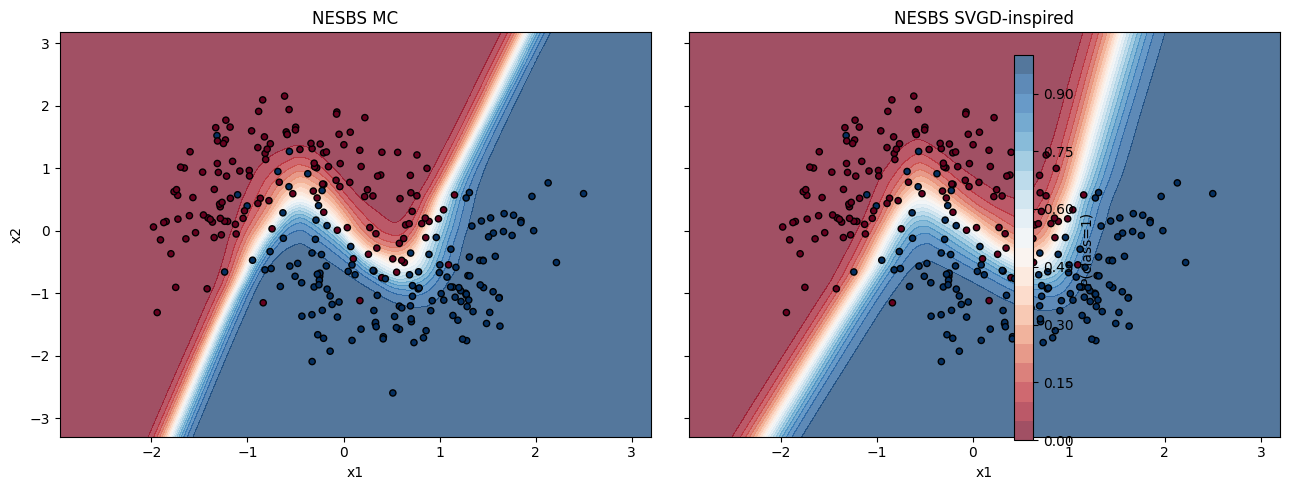

In [7]:
# 6) Визуализация decision boundary

def predict_grid(ensemble, X_ref, steps=220):
    x_min, x_max = X_ref[:, 0].min() - 0.7, X_ref[:, 0].max() + 0.7
    y_min, y_max = X_ref[:, 1].min() - 0.7, X_ref[:, 1].max() + 0.7

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, steps),
        np.linspace(y_min, y_max, steps),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_t = torch.tensor(grid, dtype=torch.float32, device=DEVICE)

    ensemble.to(DEVICE)
    ensemble.eval()
    with torch.no_grad():
        probs = torch.softmax(ensemble(grid_t), dim=-1)[:, 1].detach().cpu().numpy()

    return xx, yy, probs.reshape(xx.shape)

xx, yy, zz_mc = predict_grid(ensemble_mc, X)
_, _, zz_svgd = predict_grid(ensemble_svgd, X)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

for ax, zz, title in [
    (axes[0], zz_mc, "NESBS MC"),
    (axes[1], zz_svgd, "NESBS SVGD-inspired"),
]:
    cntr = ax.contourf(xx, yy, zz, levels=20, alpha=0.7, cmap="RdBu")
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="RdBu", edgecolor="k", s=20)
    ax.set_title(title)
    ax.set_xlabel("x1")

axes[0].set_ylabel("x2")
fig.colorbar(cntr, ax=axes.ravel().tolist(), label="P(class=1)")
plt.tight_layout()
plt.show()


## Что дальше попробовать можно?

- Увеличить `pool_size` и `ensemble_size`.
- Подобрать `temperature` (острота апостериора) и `diversity_weight`.
- Заменить toy-пространство на ваш `SearchSpace` с реальными архитектурами.
- Для более честного сравнения сделать несколько прогонов с разными `SEED`.
